In [66]:
# import metric

In [67]:
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "test2.png"
output_path = "output.svg"
img = PILImage.open(input_path)

In [68]:

def scale_svg_to_384(svg_code: str, size: int) -> str:

    # Compute scale factor
    scale_factor = 384 / size  # (e.g., 1.5 if size=256)

    # 1. Insert <g transform="scale(...)" after opening <svg ...>
    svg_code = svg_code.replace(
        '>',
        f'><g transform="scale({scale_factor})">',
        1  # only replace the first '>'
    )

    # 2. Close </g> before closing </svg>
    svg_code = svg_code.replace(
        '\n</svg>',
        '</g></svg>'
    )

    return svg_code

import re

def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code




def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white" fill="none"/>'
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        with open(output_path, "r", encoding="utf-8") as f:
            svg_code = f.read()

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
               

        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length + 30 <= max_svg_length: # acount for adding scale <\g> + injection
            break
        else:
            layer_difference += 10

    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length
    svg_code = scale_svg_to_384(svg_code, size) # this adds roughly 30 bytes

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")
      

    return svg_code

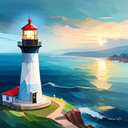

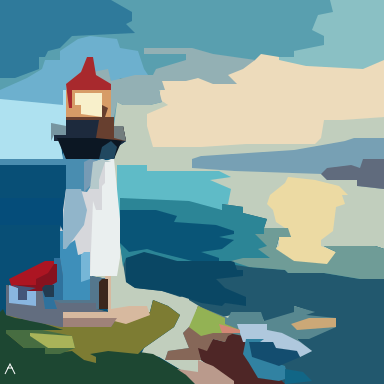

<svg viewBox="0 0 384 384" version="1.1" xmlns="http://www.w3.org/2000/svg" width="384" height="384"><g transform="scale(3.0)">
<path d="M0,0 L128,0 L128,128 L0,128 Z " fill="#C1CEBD" transform="translate(0,0)"/>
<path d="M0,0 L128,0 L128,20 L121,23 L102,22 L90,19 L86,20 L76,25 L79,28 L71,28 L66,26 L62,27 L54,27 L55,30 L53,30 L54,34 L50,35 L41,35 L39,34 L38,42 L41,42 L42,47 L39,49 L38,53 L31,54 L31,61 L29,64 L22,63 L22,73 L21,77 L21,100 L30,100 L30,92 L36,93 L36,104 L21,104 L21,106 L39,106 L42,107 L50,104 L51,100 L56,102 L60,105 L58,109 L48,116 L47,118 L53,119 L63,125 L65,128 L0,128 Z " fill="#599FAF" transform="translate(0,0)"/>
<path d="M0,0 L23,0 L34,4 L34,2 L41,3 L41,5 L49,7 L48,10 L56,10 L57,13 L53,13 L52,17 L58,21 L69,22 L72,18 L68,16 L85,16 L88,17 L88,62 L38,62 L27,54 L25,48 L29,50 L31,47 L35,48 L36,45 L41,46 L42,47 L51,48 L52,50 L59,51 L63,51 L58,46 L63,46 L72,42 L72,41 L62,40 L61,38 L64,38 L58,36 L59,39 L52,41 L48,41 L47,39 L37,39 L33,40 L23,34 L23,32 L20,33 L14,31 L5,30 L2,28

In [69]:
svg_code = bitmap_to_svg_layered(img, input_path, output_path)

# Show the original PNG (resized)
display(Image(filename=input_path))

# Show the SVG result
display(SVG(svg_code))

# Print raw SVG XML code and its length
print(svg_code)
print(len(svg_code))
print(len(svg_code.splitlines()))